In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

In [4]:
# Load dataset, data_gen.py can be used to genreate the xauusd_macro.csv file if you don't have it
df = pd.read_csv("xauusd_macro.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded {len(df)} rows | {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")


Loaded 4041 rows | 2010-01-04 → 2026-01-30


In [5]:
# Helper functions to calcuate rsi, atr, macd indicators
def rsi(s, w=14):
    d = s.diff()
    g = d.clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    l = (-d).clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    return 100 - (100 / (1 + g / l.replace(0, np.nan)))

def atr(h, l, c, w=14):
    pc = c.shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/w, adjust=False).mean()

def macd_hist(c, f=12, s=26, sig=9):
    line = c.ewm(span=f, adjust=False).mean() - c.ewm(span=s, adjust=False).mean()
    return line - line.ewm(span=sig, adjust=False).mean()

In [6]:
# Builds features for the model, including original 10 features and new macro features
def build_features(df):
    d = df.copy()
    c, h, l = d["Close"], d["High"], d["Low"]
    dxy, vix, oil = d["DXY_Close"], d["VIX_Close"], d["Oil_Close"]
    ret1 = c.pct_change()

    # original 10 features 
    d["macd_hist"]     = macd_hist(c) / c
    d["rsi_14"]        = rsi(c)
    d["atr_pct"]       = atr(h, l, c) / c
    d["ret_5"]         = c.pct_change(5)
    d["ret_21"]        = c.pct_change(21)
    d["vol_ratio"]     = ret1.rolling(5).std() / ret1.rolling(21).std().replace(0, np.nan)
    d["dxy_ret5"]      = dxy.pct_change(5)
    d["vix_chg"]       = vix.diff()
    d["oil_ret5"]      = oil.pct_change(5)
    d["gold_dxy_corr"] = ret1.rolling(21).corr(dxy.pct_change())

    # NEW: macro features from xauusd_macro.csv 
    # These columns already exist in the CSV — we just need to
    # compute changes and normalise where needed

    # Real yield momentum (most important gold driver)
    d["real_yield_chg"]    = d["real_yield_10y"].diff()
    d["real_yield_5d_chg"] = d["real_yield_10y"].diff(5)

    # Breakeven inflation change
    d["breakeven_chg"]     = d["breakeven_10y"].diff()

    # High yield spread change (risk appetite)
    d["hy_spread_chg"]     = d["hy_spread"].diff()

    # Rate change direction ( had some issues in calcuating this, we will fix it later on)
    # d["rate_change"]       = d["fed_funds_rate"].diff().fillna(0)

    # GPR normalised (z-score over rolling 63 days)
    if "gpr_index" in d.columns:
        gpr_mean = d["gpr_index"].rolling(63).mean()
        gpr_std  = d["gpr_index"].rolling(63).std().replace(0, np.nan)
        d["gpr_zscore"] = (d["gpr_index"] - gpr_mean) / gpr_std
    else:
        d["gpr_zscore"] = 0.0

    return d

df = build_features(df)

In [7]:
FEATURES = [
    # Original 10 — keep all of these
    "macd_hist", 
    "rsi_14", 
    "atr_pct", 
    "ret_5", 
    "ret_21",
    "vol_ratio", 
    "dxy_ret5", 
    "vix_chg", 
    "oil_ret5", 
    "gold_dxy_corr",

    # Macro — changes and flags only (no levels)
    "real_yield_chg",
    "real_yield_5d_chg",
    "breakeven_chg",
    "hy_spread_chg",
    "fomc_week",
    "macro_event_week",
    "gpr_zscore",

    # # Real yield — strongest structural gold driver
    # # "real_yield_10y",       # level
    # "real_yield_chg",       # 1-day change
    # "real_yield_5d_chg",    # 5-day momentum

    # # Inflation expectations
    # "breakeven_10y",        # level
    # "breakeven_chg",        # 1-day change

    # # Fed / rates
    # # "fed_funds_rate",        # current rate level
    # # "rate_change",          # rate hike/cut signal

    # # Risk appetite
    # "hy_spread_chg",        # high yield spread change

    # # Event flags — binary signals
    # "fomc_week",            # 1 if within 3 days of FOMC
    # "days_to_fomc",         # countdown to next meeting
    # "days_to_cpi",          # countdown to next CPI
    # "days_to_nfp",          # countdown to next NFP
    # "macro_event_week",     # 1 if any major event within 3 days

    # # Geopolitical risk
    # "gpr_zscore",           # normalised GPR (z-score vs recent history)
]

In [8]:
FWD      = 5
LOOKBACK = 15

# 4. Labelling — top/bottom 30% quantile(can be adjusted to 40/60 for more balanced classes)
df["fwd_ret_5"] = df["Close"].shift(-FWD) / df["Close"] - 1
q_lo = df["fwd_ret_5"].quantile(0.40)
q_hi = df["fwd_ret_5"].quantile(0.60)
df["label"] = np.nan
df.loc[df["fwd_ret_5"] >= q_hi, "label"] = 1
df.loc[df["fwd_ret_5"] <= q_lo, "label"] = 0

# MIN_RET = 0.008   # minimum 0.8% move to be labeled so that to handle netural days
# q_lo = df["fwd_ret_5"].quantile(0.30)   # tighter: was 0.30
# q_hi = df["fwd_ret_5"].quantile(0.70)   # tighter: was 0.70
# df["label"] = np.nan
# df.loc[(df["fwd_ret_5"] >= q_hi) & (df["fwd_ret_5"] >  MIN_RET), "label"] = 1
# df.loc[(df["fwd_ret_5"] <= q_lo) & (df["fwd_ret_5"] < -MIN_RET), "label"] = 0

df_clean = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)

# filter only after 2025-08-01 to focus on recent data
# df_clean = df_clean[df_clean["Date"] < "2025-08-01"].reset_index(drop=True)

print(f"Rows after dropna: {len(df_clean)}")
print(f"Date range: {df_clean['Date'].iloc[0].date()} → {df_clean['Date'].iloc[-1].date()}")


Rows after dropna: 3210
Date range: 2010-02-03 → 2026-01-23


In [9]:
TRAIN_END = "2022-12-31"   # train includes 2022 rate hike peak
VAL_END   = "2024-03-31" 

tr = df_clean[df_clean["Date"] <= TRAIN_END]
va = df_clean[(df_clean["Date"] > TRAIN_END) & (df_clean["Date"] <= VAL_END)]
te = df_clean[df_clean["Date"] > VAL_END].copy()

sc    = StandardScaler()
Xtr   = sc.fit_transform(tr[FEATURES])
Xva   = sc.transform(va[FEATURES])
Xte   = sc.transform(te[FEATURES])
ytr   = tr["label"].astype(int).values
yva   = va["label"].astype(int).values
yte   = te["label"].astype(int).values

def make_seq(X, y, lb):
    Xs, ys = [], []
    for i in range(lb, len(X)):
        Xs.append(X[i-lb:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

Xtr_s, ytr_s = make_seq(Xtr, ytr, LOOKBACK)
Xva_s, yva_s = make_seq(Xva, yva, LOOKBACK)
Xte_s, yte_s = make_seq(Xte, yte, LOOKBACK)

In [11]:
# 6. Train model
print("Training LSTM...")
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=ytr_s)

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURES))),
    layers.LSTM(24),
    layers.Dropout(0.4),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss="binary_crossentropy", metrics=["accuracy"])
model.fit(Xtr_s, ytr_s,
          validation_data=(Xva_s, yva_s),
          epochs=80, batch_size=32,
          class_weight={0: cw[0], 1: cw[1]},
          callbacks=[
              callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                      restore_best_weights=True, verbose=0),
              callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=5, verbose=0),
          ], verbose=0)
print("Training done.")

# check MSE accuracy precision recall
loss, acc = model.evaluate(Xva_s, yva_s, verbose=0)
print(f"Validation Accuracy: {acc:.4f}")    


Training LSTM...
Training done.
Validation Accuracy: 0.5633


In [12]:
# Metrics: Accuracy, MSE, Precision, Recall, F1
from sklearn.metrics import accuracy_score, mean_squared_error, precision_score, recall_score, f1_score

prob = model.predict(Xte_s, verbose=0).flatten()

# Validation predictions
val_prob = model.predict(Xva_s, verbose=0).flatten()
val_pred = (val_prob >= 0.5).astype(int)

# Test predictions (already computed as `prob`)
test_prob = prob
test_pred = (test_prob >= 0.5).astype(int)

print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_score(yva_s, val_pred):.4f}")
print(f"MSE(prob): {mean_squared_error(yva_s, val_prob):.4f}")
print(f"MSE(pred): {mean_squared_error(yva_s, val_pred):.4f}")
print(f"Precision: {precision_score(yva_s, val_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yva_s, val_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(yva_s, val_pred, zero_division=0):.4f}")

print("\n=== Test Metrics ===")
print(f"Accuracy : {accuracy_score(yte_s, test_pred):.4f}")
print(f"MSE(prob): {mean_squared_error(yte_s, test_prob):.4f}")
print(f"MSE(pred): {mean_squared_error(yte_s, test_pred):.4f}")
print(f"Precision: {precision_score(yte_s, test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yte_s, test_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(yte_s, test_pred, zero_division=0):.4f}")

=== Validation Metrics ===
Accuracy : 0.5633
MSE(prob): 0.2479
MSE(pred): 0.4367
Precision: 0.5294
Recall   : 0.5888
F1-score : 0.5575

=== Test Metrics ===
Accuracy : 0.5847
MSE(prob): 0.2467
MSE(pred): 0.4153
Precision: 0.6680
Recall   : 0.7021
F1-score : 0.6846


In [13]:
# Remaning section contains backtesting the model with a simple strategy and plotting the equity curve and other insights. 
# This doesn't mean the model is profitable in real life as we haven't considered transaction costs, slippage, risk management, entry strategy, etc. But it can give us some insights on how the model's predictions would have performed historically.

# 7. BUILD SIGNAL DATAFRAME
#    Each row = one trade signal on that date
test_dates  = te["Date"].values[LOOKBACK:]
test_close  = te["Close"].values[LOOKBACK:]
test_fwd    = te["fwd_ret_5"].values[LOOKBACK:]
test_true   = yte_s

signal_df = pd.DataFrame({
    "Date":       test_dates,
    "Close":      test_close,
    "prob_up":    prob,
    "signal":     np.where(prob >= 0.5, 1, -1),   # 1=Long, -1=Short
    "true_label": test_true,
    "fwd_ret_5":  test_fwd,
})
signal_df["Date"] = pd.to_datetime(signal_df["Date"])

In [14]:
# 8. BACKTEST ENGINE
#  Rules:
#  - Hold each position for exactly FWD=5 days
#  - Only one position at a time (no overlapping trades)
#  - Entry at Close on signal day
#  - Exit at Close 5 days later
#  - Transaction cost = spread (adjustable)
#  - Position size = fixed fraction of equity

INITIAL_CAPITAL   = 100_000     # USD
POSITION_SIZE_PCT = 1.00       # risk 10% of equity per trade
SPREAD_PCT        = 0.0002     # 0.02% round-trip spread (realistic for XAUUSD)
CONF_THRESHOLD    = 0.25   # only trade on more confident predictions
STOP_LOSS_PCT     = 0.015  # 1.5% stop loss - can be adjusted

def run_backtest(signal_df, initial_capital, pos_size_pct,
                 spread_pct, conf_threshold, stop_loss_pct, label="Strategy"):
    """
    Stop-loss logic:
      - We don't have intraday data, so we simulate stop on daily closes.
      - For each trade day between entry and exit, if the daily close
        moves more than stop_loss_pct against the position, we exit early
        using that day's close as the exit price.
      - This is conservative (real stops would trigger intraday).
    """
    equity       = initial_capital
    equity_curve = [equity]
    dates_curve  = [signal_df["Date"].iloc[0]]
    trades       = []
    i            = 0

    # Merge close prices back by date for stop-loss checking
    close_by_date = signal_df.set_index("Date")["Close"]

    while i < len(signal_df):
        row = signal_df.iloc[i]

        # Skip if not confident enough
        confident = (row["prob_up"] >= conf_threshold) or \
                    (row["prob_up"] <= (1 - conf_threshold))
        if not confident:
            i += 1
            equity_curve.append(equity)
            dates_curve.append(row["Date"])
            continue

        direction   = 1 if row["prob_up"] >= 0.5 else -1
        entry_price = row["Close"]
        entry_date  = row["Date"]

        # Check stop loss on each day until exit
        stopped_out = False
        exit_price  = entry_price * (1 + row["fwd_ret_5"])   # default: full hold
        exit_date   = entry_date + pd.Timedelta(days=FWD)

        # Look at closes over the next FWD days in signal_df
        future = signal_df.iloc[i+1 : i+FWD+1]
        for _, frow in future.iterrows():
            daily_move = direction * (frow["Close"] / entry_price - 1)
            if daily_move <= -stop_loss_pct:
                # Stop triggered — exit at this day's close
                exit_price  = frow["Close"]
                exit_date   = frow["Date"]
                stopped_out = True
                break

        position_value = equity * pos_size_pct
        gross_ret      = direction * (exit_price / entry_price - 1)
        net_ret        = gross_ret - spread_pct
        pnl            = position_value * net_ret
        equity        += pnl

        trades.append({
            "entry_date":   entry_date,
            "exit_date":    exit_date,
            "direction":    "Long" if direction == 1 else "Short",
            "entry_price":  round(entry_price, 2),
            "exit_price":   round(exit_price, 2),
            "gross_ret":    round(gross_ret * 100, 3),
            "net_ret":      round(net_ret * 100, 3),
            "pnl":          round(pnl, 2),
            "equity":       round(equity, 2),
            "win":          pnl > 0,
            "stopped_out":  stopped_out,
        })

        i += FWD
        equity_curve.append(equity)
        dates_curve.append(row["Date"])

    trades_df = pd.DataFrame(trades)
    eq_df     = pd.DataFrame({"Date": dates_curve, "Equity": equity_curve})
    return trades_df, eq_df

In [15]:
# 9. Run Backtest
trades_df, eq_df = run_backtest(
    signal_df, INITIAL_CAPITAL, POSITION_SIZE_PCT,
    SPREAD_PCT, CONF_THRESHOLD, STOP_LOSS_PCT, "LSTM Strategy"
)

# Buy-and-hold benchmark for comparison
bh_ret    = (signal_df["Close"].iloc[-1] / signal_df["Close"].iloc[0]) - 1
bh_equity = INITIAL_CAPITAL * (1 + bh_ret * POSITION_SIZE_PCT)

# bh_equity = INITIAL_CAPITAL * (1 + bh_ret)

In [16]:
# 10. Performance Metrics
def calc_performance(trades_df, eq_df, initial_capital):
    if len(trades_df) == 0:
        print("No trades executed.")
        return

    final_eq      = eq_df["Equity"].iloc[-1]
    total_return  = (final_eq - initial_capital) / initial_capital * 100
    wins          = trades_df["win"].sum()
    losses        = (~trades_df["win"]).sum()
    win_rate      = wins / len(trades_df) * 100
    avg_win       = trades_df.loc[trades_df["win"],  "net_ret"].mean()
    avg_loss      = trades_df.loc[~trades_df["win"], "net_ret"].mean()
    profit_factor = (trades_df.loc[trades_df["win"],  "pnl"].sum() /
                     abs(trades_df.loc[~trades_df["win"], "pnl"].sum())
                     if losses > 0 else np.inf)

    # Drawdown
    eq_series  = eq_df["Equity"]
    roll_max   = eq_series.cummax()
    drawdown   = (eq_series - roll_max) / roll_max * 100
    max_dd     = drawdown.min()

    # Annualized return (approximate)
    n_days     = (eq_df["Date"].iloc[-1] - eq_df["Date"].iloc[0]).days
    ann_return = ((final_eq / initial_capital) ** (365 / max(n_days, 1)) - 1) * 100

    # Sharpe (simplified — using trade returns)
    trade_rets = trades_df["net_ret"].values / 100
    sharpe     = (trade_rets.mean() / trade_rets.std() * np.sqrt(252 / FWD)
                  if trade_rets.std() > 0 else 0)

    print("\n" + "="*55)
    print("BACKTEST PERFORMANCE REPORT")
    print("="*55)
    print(f"\n  {'Initial Capital':<30} ${initial_capital:>10,.2f}")
    print(f"  {'Final Equity':<30} ${final_eq:>10,.2f}")
    print(f"  {'Total Return':<30} {total_return:>+10.2f}%")
    print(f"  {'Annualized Return':<30} {ann_return:>+10.2f}%")
    print(f"\n  {'Total Trades':<30} {len(trades_df):>10}")
    print(f"  {'Wins':<30} {wins:>10}")
    print(f"  {'Losses':<30} {losses:>10}")
    print(f"  {'Win Rate':<30} {win_rate:>10.1f}%")
    print(f"  {'Avg Win':<30} {avg_win:>+10.3f}%")
    print(f"  {'Avg Loss':<30} {avg_loss:>+10.3f}%")
    print(f"  {'Profit Factor':<30} {profit_factor:>10.2f}")
    print(f"  {'Max Drawdown':<30} {max_dd:>10.2f}%")
    print(f"  {'Sharpe Ratio':<30} {sharpe:>10.2f}")
    print(f"\n  {'Spread cost per trade':<30} {SPREAD_PCT*100:>10.3f}%")
    print(f"  {'Position size':<30} {POSITION_SIZE_PCT*100:>10.0f}% of equity")
    print(f"  {'Hold period':<30} {FWD:>10} days")

    print(f"\n  {'Buy & Hold return (same size)':<30} {(bh_equity-initial_capital)/initial_capital*100:>+10.2f}%")

    return {
        "total_return": total_return,
        "win_rate": win_rate,
        "max_dd": max_dd,
        "sharpe": sharpe,
        "profit_factor": profit_factor,
    }

perf = calc_performance(trades_df, eq_df, INITIAL_CAPITAL)

# Show last 10 trades
print("\nLast 10 trades:")
print(trades_df[["entry_date","direction","entry_price","exit_price",
                  "gross_ret","net_ret","pnl","equity"]].tail(10).to_string(index=False))



BACKTEST PERFORMANCE REPORT

  Initial Capital                $100,000.00
  Final Equity                   $150,214.02
  Total Return                       +50.21%
  Annualized Return                  +26.12%

  Total Trades                           74
  Wins                                   41
  Losses                                 33
  Win Rate                             55.4%
  Avg Win                            +2.771%
  Avg Loss                           -2.111%
  Profit Factor                        1.60
  Max Drawdown                       -12.02%
  Sharpe Ratio                         1.44

  Spread cost per trade               0.020%
  Position size                         100% of equity
  Hold period                             5 days

  Buy & Hold return (same size)     +113.78%

Last 10 trades:
entry_date direction  entry_price  exit_price  gross_ret  net_ret      pnl    equity
2025-11-11     Short       4106.8      4204.4     -2.377   -2.397 -3192.72 130028.69
2025-1

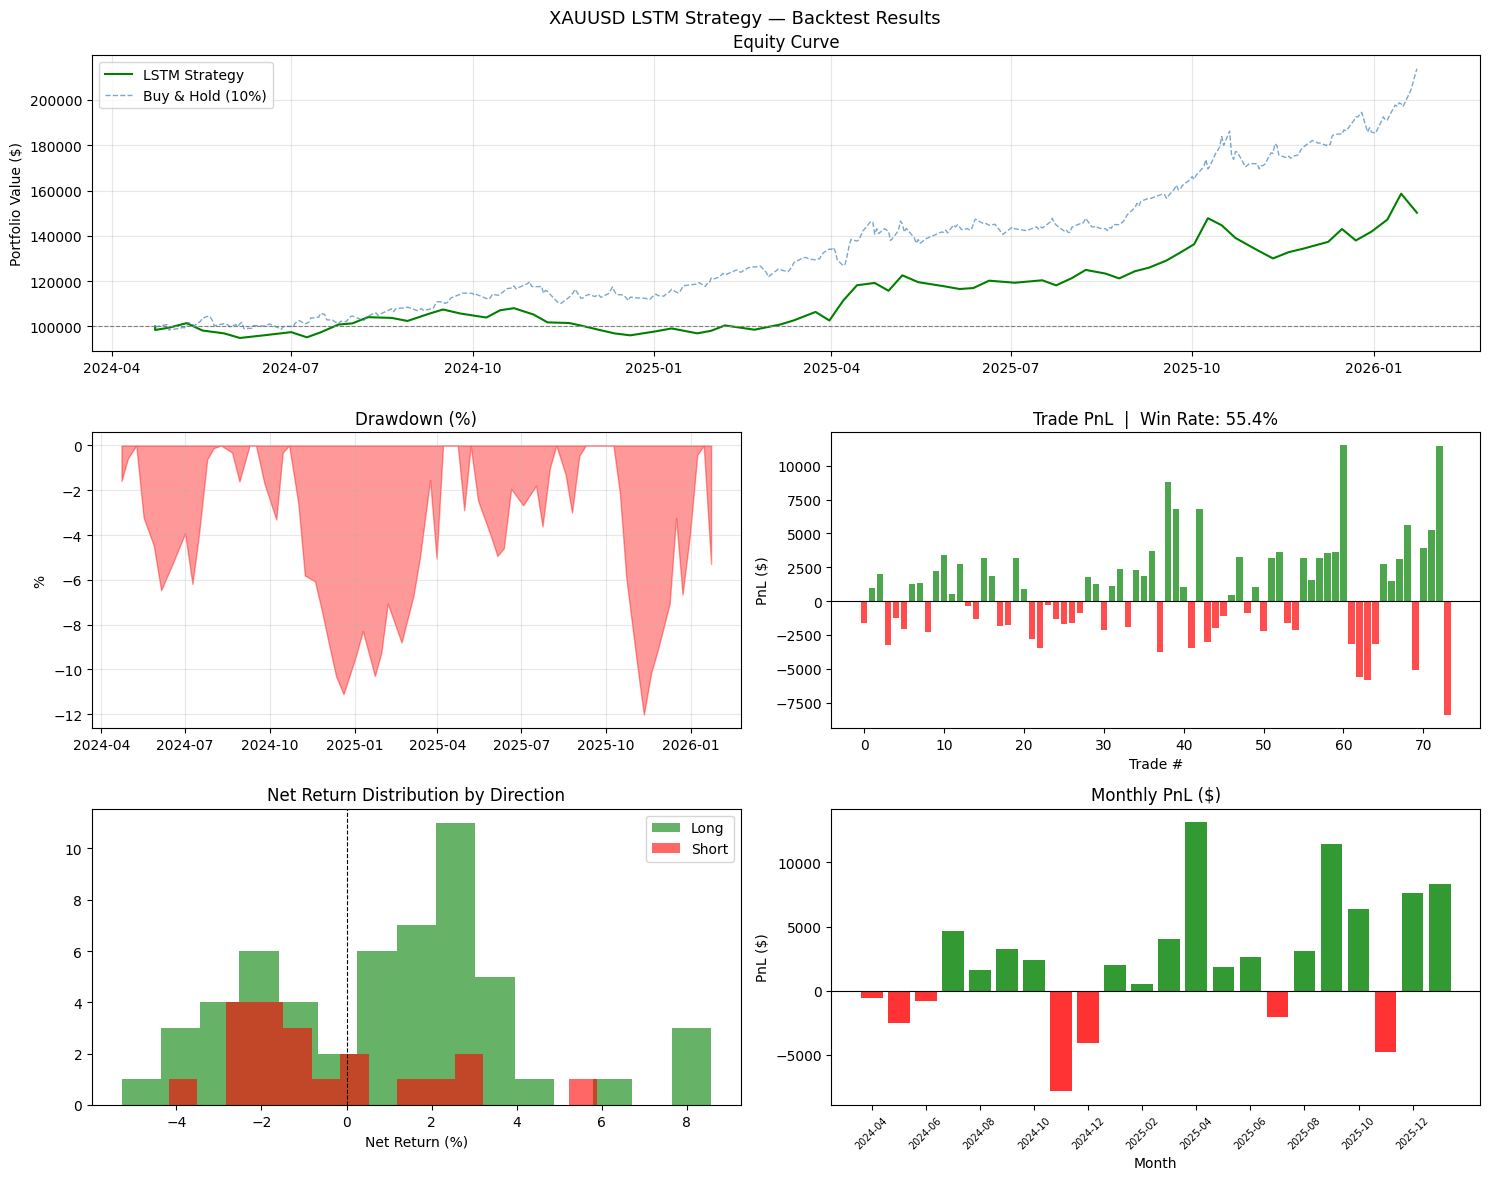

In [17]:
# 11. Plots
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig)
fig.suptitle("XAUUSD LSTM Strategy — Backtest Results", fontsize=13)

# Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(eq_df["Date"], eq_df["Equity"], color="green",
         linewidth=1.5, label="LSTM Strategy")
ax1.axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=0.8)
# Mark buy and hold
bh_curve = INITIAL_CAPITAL + (signal_df["Close"] / signal_df["Close"].iloc[0] - 1) * INITIAL_CAPITAL * POSITION_SIZE_PCT
ax1.plot(signal_df["Date"], bh_curve, color="steelblue",
         linewidth=1.0, linestyle="--", alpha=0.7, label="Buy & Hold (10%)")
ax1.set_title("Equity Curve")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
eq_series = eq_df["Equity"]
roll_max  = eq_series.cummax()
drawdown  = (eq_series - roll_max) / roll_max * 100
ax2.fill_between(eq_df["Date"], drawdown, 0, color="red", alpha=0.4)
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("%")
ax2.grid(alpha=0.3)

# Trade PnL distribution
ax3 = fig.add_subplot(gs[1, 1])
colors_pnl = ["green" if w else "red" for w in trades_df["win"]]
ax3.bar(range(len(trades_df)), trades_df["pnl"], color=colors_pnl, alpha=0.7)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title(f"Trade PnL  |  Win Rate: {trades_df['win'].mean()*100:.1f}%")
ax3.set_xlabel("Trade #")
ax3.set_ylabel("PnL ($)")

# Win/loss by direction
ax4 = fig.add_subplot(gs[2, 0])
for direction, color in [("Long", "green"), ("Short", "red")]:
    sub = trades_df[trades_df["direction"] == direction]["net_ret"]
    if len(sub) > 0:
        ax4.hist(sub, bins=15, alpha=0.6, color=color, label=direction)
ax4.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax4.set_title("Net Return Distribution by Direction")
ax4.set_xlabel("Net Return (%)")
ax4.legend()

# Monthly returns heatmap
ax5 = fig.add_subplot(gs[2, 1])
if len(trades_df) > 0:
    trades_df["entry_date"] = pd.to_datetime(trades_df["entry_date"])
    trades_df["month"] = trades_df["entry_date"].dt.to_period("M")
    monthly = trades_df.groupby("month")["pnl"].sum().reset_index()
    monthly["month_str"] = monthly["month"].astype(str)
    colors_m = ["green" if p > 0 else "red" for p in monthly["pnl"]]
    ax5.bar(range(len(monthly)), monthly["pnl"], color=colors_m, alpha=0.8)
    ax5.axhline(0, color="black", linewidth=0.8)
    ax5.set_title("Monthly PnL ($)")
    ax5.set_xlabel("Month")
    ax5.set_ylabel("PnL ($)")
    step = max(1, len(monthly)//8)
    ax5.set_xticks(range(0, len(monthly), step))
    ax5.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=7)

plt.tight_layout()
# plt.savefig("xauusd_backtest.png", dpi=150)
plt.show()

In [ ]:
# 12. Export trades to CSV if needed
# trades_df.to_csv("xauusd_trades.csv", index=False)
# print("Trades saved to: xauusd_trades.csv")